# Task 2 Strategy Handoff

This notebook is a compact, review-friendly handoff for HW1 Task 2. It summarizes the final trade-filter strategy, validation results, public-regime checks, and tail-risk diagnostics. The full research log is in `reports/task2_experiment_log.md`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name == "notebooks" else CWD
TABLES = ROOT / "reports" / "tables"
print("ROOT:", ROOT)
print("TABLES exists:", TABLES.exists())

ROOT: D:\Python\CMF\HFT_School\Task_2
TABLES exists: True


## Final Strategy

The submission function is `src/task2_solution.py::predict`. It returns one binary flag array per horizon: `0 = keep`, `1 = filter`.

In [2]:
strategy = pd.DataFrame([
    {"horizon": "30s", "rule": "BTC return5s > 50 bps, ETH return5s > 100 bps", "reason": "short-term maker reversal signal; ETH needs stricter selection"},
    {"horizon": "120s", "rule": "liq2s_d200 > 2m AND return5s > 20 bps", "reason": "liquidation pressure plus softer return guard improved public-regime 120s"},
    {"horizon": "300s", "rule": "liq2s_d200 > 2m", "reason": "plain 2s liquidation pressure was more robust than combo guards on public_extra"},
])
display(strategy)

,horizon,rule,reason
0,30s,"BTC return5s > 50 bps, ETH return5s > 100 bps",short-term maker reversal signal; ETH needs st...
1,120s,liq2s_d200 > 2m AND return5s > 20 bps,liquidation pressure plus softer return guard ...
2,300s,liq2s_d200 > 2m,plain 2s liquidation pressure was more robust ...


## Exact First-Week Validation

This exact run uses the implemented `predict` on the full trade stream for 2026-02-01 through 2026-02-07.

In [3]:
exact = pd.read_csv(TABLES / "task2_candidate_exact_20260201_07_summary_overall.csv")
exact_view = exact[["horizon_s", "score", "pnl_kept", "kept_turnover_per_day", "constraint_ok", "kept_trade_count"]].copy()
exact_view["kept_turnover_per_day"] = exact_view["kept_turnover_per_day"].map(lambda x: f"${x/1e6:.1f}M")
display(exact_view.round(4))

,horizon_s,score,pnl_kept,kept_turnover_per_day,constraint_ok,kept_trade_count
0,30,76.4753,76.5131,$65.3M,True,189780
1,120,26.6917,26.7553,$71.1M,True,123649
2,300,18.2710,18.3293,$71.1M,True,123649


## Public 6-Month Screen

The public screen uses `trade_stride=10` over 2025-11-01 through 2026-04-28. It was used for model selection and anti-overfit checks.

horizon_s,30s,120s,300s
variant,,,
current_hybrid,20.6530,6.9457,7.7372
eth100_btc50_liq2_long,35.1926,18.4605,18.6190
eth100_btc50_liq2_and_ret20_long,35.1926,27.7020,27.2266
eth100_btc50_ret5_long,35.1926,30.0280,32.0859


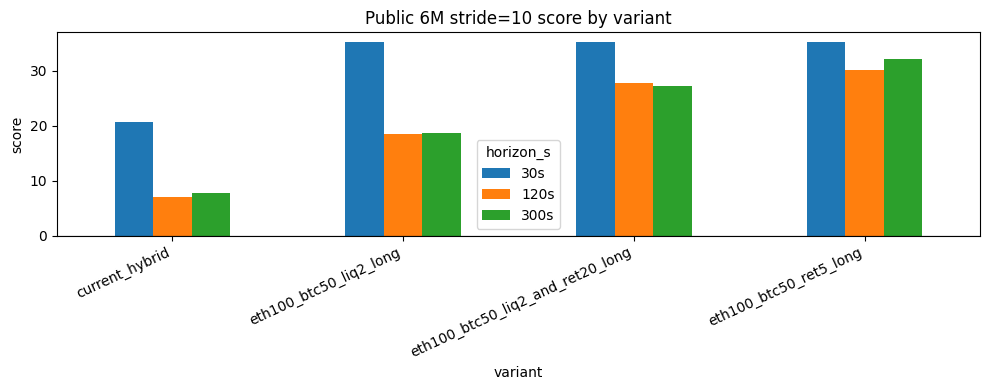

In [4]:
overall = pd.read_csv(TABLES / "task2_variant_public6m_stride10_v4_combo_summary_overall.csv")
selected = ["current_hybrid", "eth100_btc50_liq2_long", "eth100_btc50_liq2_and_ret20_long", "eth100_btc50_ret5_long"]
summary = (overall[overall["variant"].isin(selected)]
           .pivot(index="variant", columns="horizon_s", values="score")
           .rename(columns={30: "30s", 120: "120s", 300: "300s"})
           .loc[selected])
display(summary.round(4))

ax = summary[["30s", "120s", "300s"]].plot(kind="bar", figsize=(10, 4), title="Public 6M stride=10 score by variant")
ax.set_ylabel("score")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Public-Extra Robustness

`public_extra` is the most important sanity check because several attractive candidates looked strong on train/validation but failed outside the official period.

horizon_s,30s,120s,300s
variant,,,
current_hybrid,-2.9740,-0.8506,-2.2403
eth100_btc50_liq2_long,6.8345,4.6600,3.1897
eth100_btc50_liq2_and_ret20_long,6.8345,4.6857,-1.1969
eth100_btc50_ret5_long,6.8345,-9.8268,-19.8047


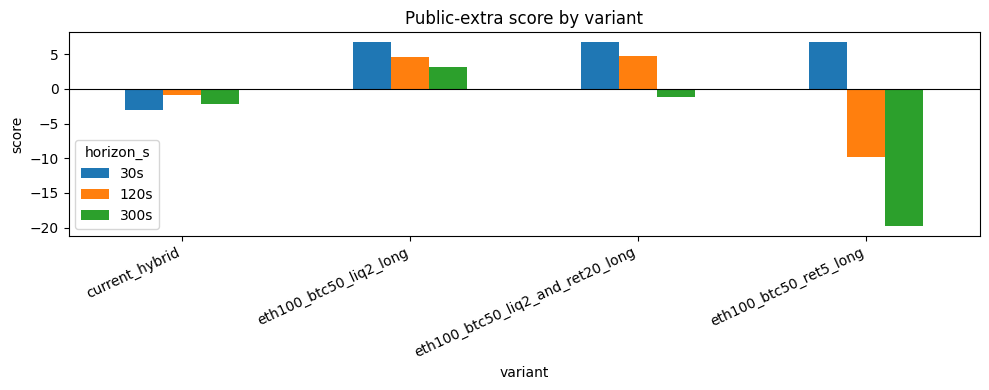

In [5]:
by_split = pd.read_csv(TABLES / "task2_variant_public6m_stride10_v4_combo_summary_by_split.csv")
public_extra = by_split[(by_split["split"] == "public_extra") & (by_split["variant"].isin(selected))]
pe = (public_extra.pivot(index="variant", columns="horizon_s", values="score")
      .rename(columns={30: "30s", 120: "120s", 300: "300s"})
      .loc[selected])
display(pe.round(4))

ax = pe[["30s", "120s", "300s"]].plot(kind="bar", figsize=(10, 4), title="Public-extra score by variant")
ax.set_ylabel("score")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Tail-Risk Diagnostics

The chosen 120s guard improves average score and reduces the worst-row minimum versus plain `liq2`. For 300s the same guard worsens public-extra, so it is not adopted for 300s.

In [6]:
daily = pd.read_csv(ROOT / "outputs_variant_public6m_stride10_v4_combo" / "variant_daily_metrics.csv")
daily["score"] = daily["pnl_kept"] - daily["pnl_all"]
rows = []
for variant in selected:
    for horizon in [30, 120, 300]:
        s = daily[(daily["variant"] == variant) & (daily["horizon_s"] == horizon)]["score"].dropna()
        rows.append({
            "variant": variant,
            "horizon_s": horizon,
            "rows": len(s),
            "negative_rows": int((s < 0).sum()),
            "min_score": s.min(),
            "p05_score": s.quantile(0.05),
            "median_score": s.median(),
        })
tail = pd.DataFrame(rows)
display(tail.round(4))

,variant,horizon_s,rows,negative_rows,min_score,p05_score,median_score
0,current_hybrid,30,119,24,-109.0765,-25.7408,17.3957
1,current_hybrid,120,358,81,-160.1879,-8.2330,6.3191
2,current_hybrid,300,358,80,-205.9992,-15.7880,8.5731
3,eth100_btc50_liq2_long,30,54,10,-94.0596,-30.1577,19.5734
4,eth100_btc50_liq2_long,120,204,80,-282.7706,-31.5338,5.8021
5,eth100_btc50_liq2_long,300,204,81,-314.1536,-38.0708,8.0665
6,eth100_btc50_liq2_and_ret20_long,30,54,10,-94.0596,-30.1577,19.5734
7,eth100_btc50_liq2_and_ret20_long,120,107,34,-68.2824,-41.0611,17.0451
8,eth100_btc50_liq2_and_ret20_long,300,107,33,-63.6859,-43.9111,18.2783
9,eth100_btc50_ret5_long,30,54,10,-94.0596,-30.1577,19.5734


## Reproducibility

Local checks:

```bash
python -m unittest discover -s tests -v
python -m py_compile src/task2_solution.py src/task2_evaluate.py src/task2_variant_research.py
```

Server evaluation example:

```bash
python3 src/task2_evaluate.py --data-root /root/CMF/Task_1 --output-dir outputs_candidate_exact_20260201_07 --start 2026-02-01 --end 2026-02-08
```

The dataset is intentionally not committed; the evaluator expects the existing Task 1 data directory on the server.